
FINAL SELECTIONS:
Severity: genexpon with params (np.float64(0.413882015952461), np.float64(4.198135182799367), np.float64(0.12224424917470304), np.float64(0.0001198241390295457), np.float64(0.3133701657170155))
Magnitude: norm with params (np.float64(2.6469244274141914), np.float64(0.6218248065628807))


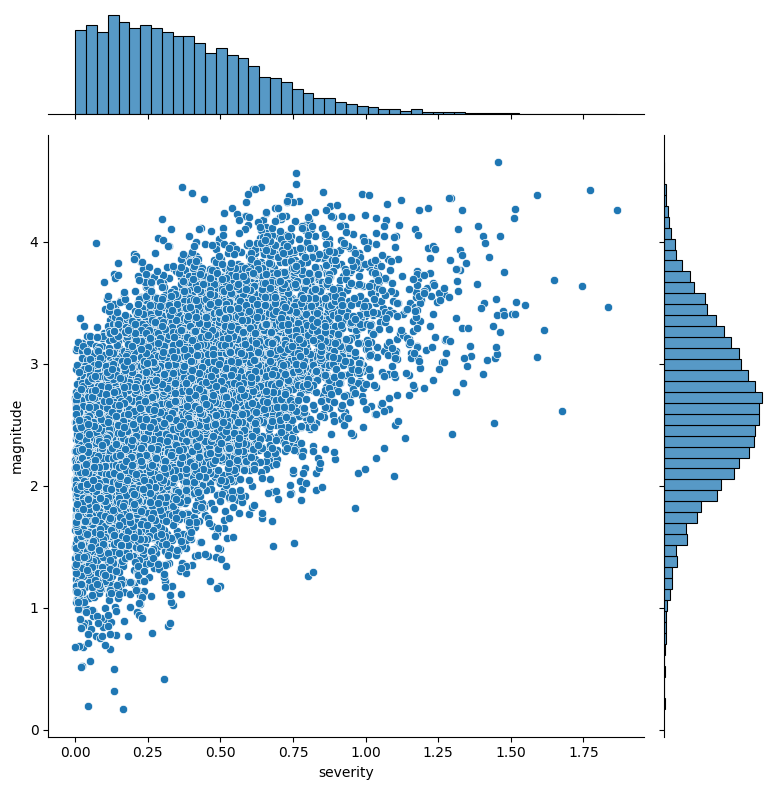

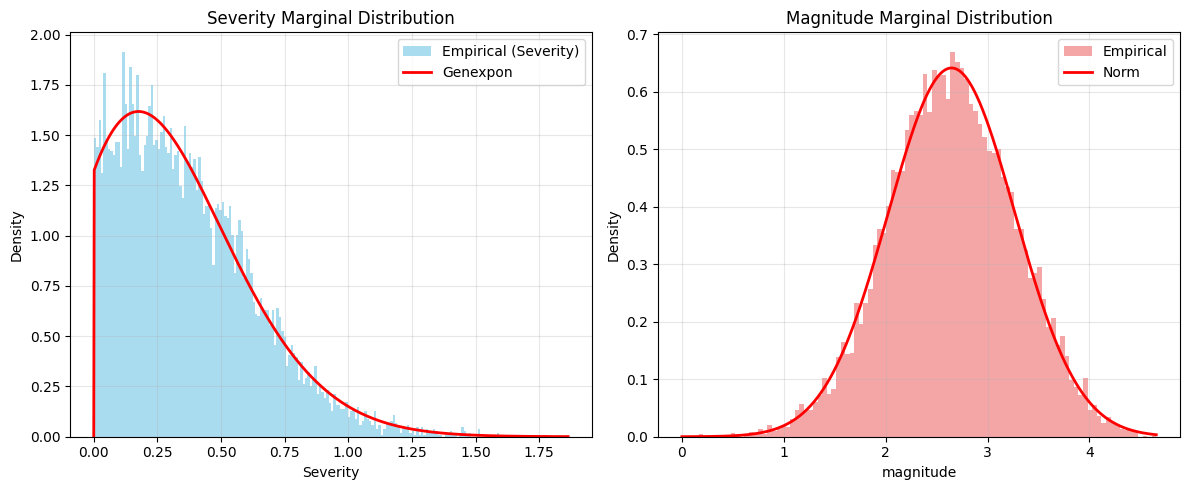

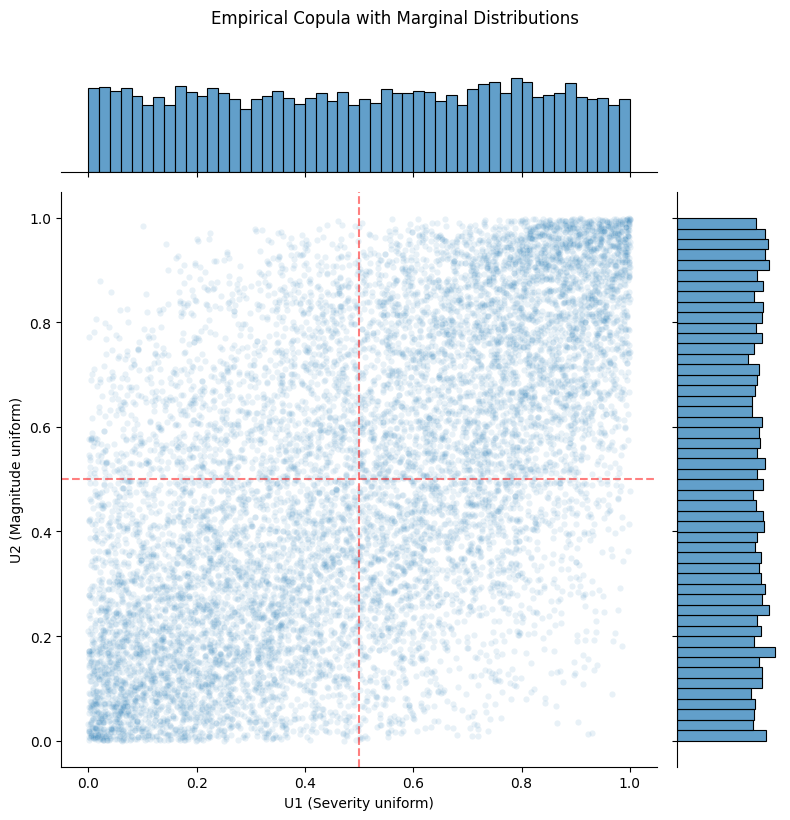

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import multivariate_t, multivariate_normal, t, norm
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# Load data
fname = "./pywrdrb/drought_metrics/stationary_ensemble_ssi12_drought_events.csv"
df = pd.read_csv(fname, index_col=0)

# Drop any rows with inf in magnitude or severity
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['magnitude', 'severity'])

df['magnitude'] = np.log(np.abs(df['magnitude']))
df['severity'] = np.log(np.abs(df['severity']))



x_col = 'severity'
y_col = 'magnitude'

# Plot joint scatter of x and y
sns.jointplot(data=df, x=x_col, y=y_col, kind="scatter", height=8, marginal_kws=dict(bins=50, fill=True))
plt.savefig("drought_joint_scatter.png", dpi=300)


### Fitting marginals
best_sev_dist = stats.genexpon
best_sev_params = best_sev_dist.fit(df['severity'])


best_mag_dist = stats.norm
best_mag_params = best_mag_dist.fit(df['magnitude'])

print(f"\nFINAL SELECTIONS:")
print(f"Severity: {best_sev_dist.name} with params {best_sev_params}")
print(f"Magnitude: {best_mag_dist.name} with params {best_mag_params}")

### Use fitted distributions to transform data to uniform
# Transform to uniform using best fitted distributions
u_severity = best_sev_dist.cdf(df['severity'], *best_sev_params)
u_magnitude = best_mag_dist.cdf(df['magnitude'], *best_mag_params)

# Update uniform data matrix for copula
U = np.column_stack([u_severity, u_magnitude])


### PLot fitted marginal distributions


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Severity marginal (using shifted data)
x_sev = np.linspace(0, df['severity'].max(), 1000)
ax1.hist(df['severity'], bins=200, density=True, alpha=0.7, color='skyblue', label='Empirical (Severity)')
ax1.plot(x_sev, best_sev_dist.pdf(x_sev, *best_sev_params), 'r-', lw=2, label=f'{best_sev_dist.name.title()}')
ax1.set_xlabel('Severity')
ax1.set_ylabel('Density')
ax1.set_title('Severity Marginal Distribution')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Magnitude marginal
x_mag = np.linspace(0, df['magnitude'].max(), 1000)
ax2.hist(df['magnitude'], bins=100, density=True, alpha=0.7, color='lightcoral', label='Empirical')
ax2.plot(x_mag, best_mag_dist.pdf(x_mag, *best_mag_params), 'r-', lw=2, label=f'{best_mag_dist.name.title()}')
ax2.set_xlabel('magnitude')
ax2.set_ylabel('Density')
ax2.set_title('Magnitude Marginal Distribution')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# plot joint distribution of marginal CDFs

# Create joint plot with marginals using seaborn
g = sns.jointplot(x=U[:, 0], y=U[:, 1], 
                 kind='scatter',
                 alpha=0.1, 
                 s=20,
                 height=8,
                 marginal_kws={'bins': 50, 'alpha': 0.7})

# Customize labels and title
g.set_axis_labels('U1 (Severity uniform)', 'U2 (Magnitude uniform)')
g.figure.suptitle('Empirical Copula with Marginal Distributions', y=1.02)

# Add reference lines for independence
g.ax_joint.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
g.ax_joint.axvline(x=0.5, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



In [2]:
df.shape

(11032, 7)

In [13]:
### Fit gaussian copula
u1 = U[:, 0]
u2 = U[:, 1]

rho = np.corrcoef(norm.ppf(u1), norm.ppf(u2))[0,1]
loglik = multivariate_normal.logpdf(
           np.column_stack([norm.ppf(u1), norm.ppf(u2)]), 
           cov=[[1, rho], [rho, 1]]
       ).sum()

best_copula = 'gaussian'
best_params = [rho]


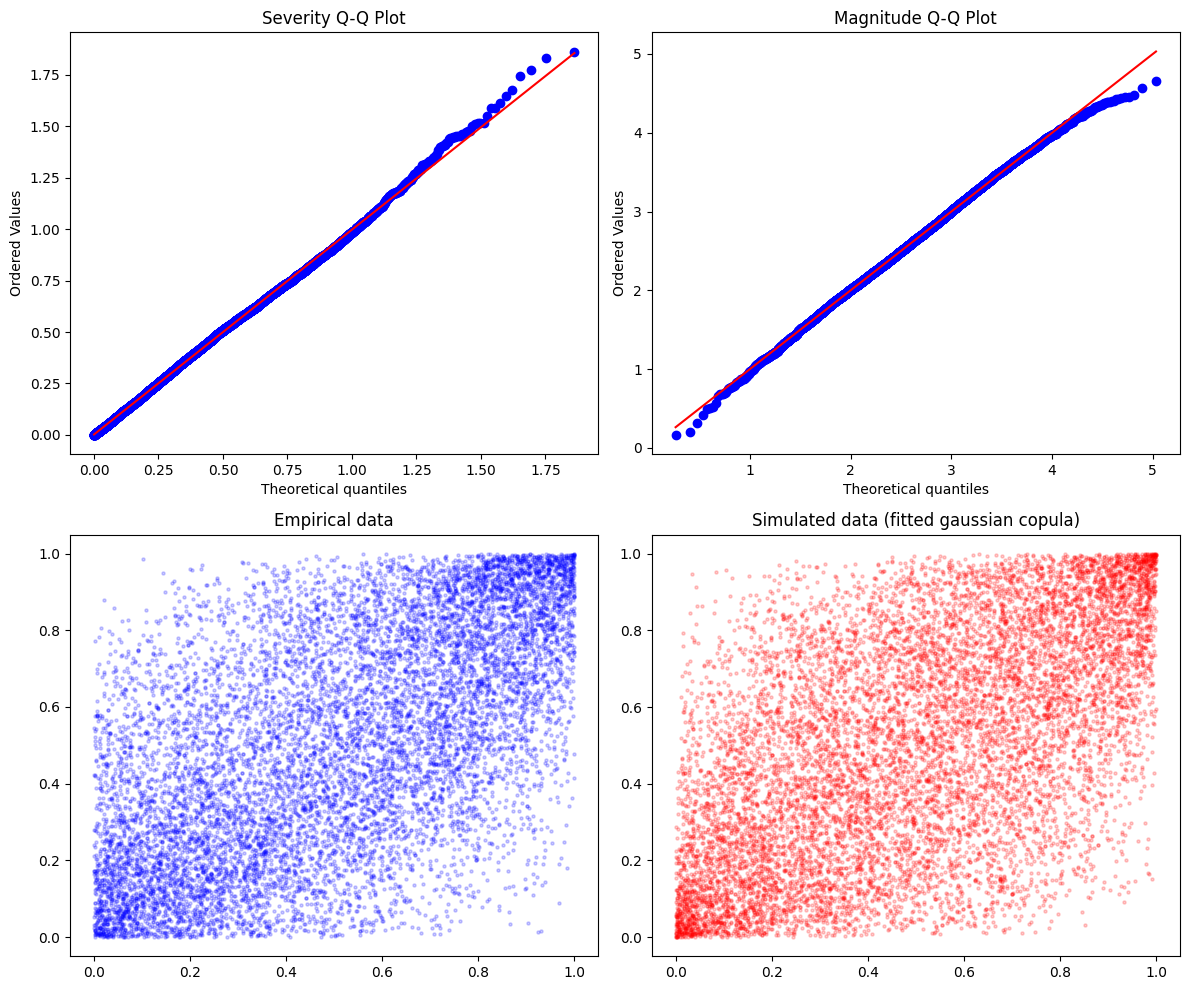

In [14]:
# 1. Visual diagnostics
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

### Marginal Q-Q plots


# Severity Q-Q plot
stats.probplot(df['severity'], dist=best_sev_dist, sparams=best_sev_params, plot=ax1)
ax1.set_title('Severity Q-Q Plot')

# Magnitude Q-Q plot  
stats.probplot(df['magnitude'], dist=best_mag_dist, sparams=best_mag_params, plot=ax2)
ax2.set_title('Magnitude Q-Q Plot')

## Compare empirical data with samples from fitted copula
n_sim = U.shape[0]

# Sample from fitted copula
rho = best_params[0]
z1, z2 = np.random.multivariate_normal([0, 0], [[1, rho], [rho, 1]], n_sim).T
u1_sim, u2_sim = stats.norm.cdf(z1), stats.norm.cdf(z2)

ax3.scatter(U[:, 0], U[:, 1], alpha=0.2, s=5, label='Empirical', color='blue')
ax4.scatter(u1_sim, u2_sim, alpha=0.2, s=5, label='Simulated', color='red')
ax3.set_title(f'Empirical data')
ax4.set_title(f'Simulated data (fitted {best_copula} copula)')

plt.tight_layout()
plt.savefig("copula_diagnostics.png", dpi=300)

In [15]:
def joint_exceedance_prob(sev_threshold, mag_threshold):
    # NOTE: thresholds must be on the same scale as the fitted marginals.
    u = best_sev_dist.cdf(sev_threshold, *best_sev_params)  # F_D(d)
    v = best_mag_dist.cdf(mag_threshold, *best_mag_params)  # F_S(s)
    z1, z2 = stats.norm.ppf(u), stats.norm.ppf(v)
    rho = best_params[0]
    C_uv = stats.multivariate_normal.cdf([z1, z2], cov=[[1, rho], [rho, 1]])
    return 1.0 - u - v + C_uv


# Individual marginal probabilities
sev_95th = best_sev_dist.ppf(0.95, *best_sev_params)
mag_95th = best_mag_dist.ppf(0.95, *best_mag_params)

print(f"95th percentile severity: {sev_95th:.2f}")
print(f"95th percentile magnitude: {mag_95th:.2f}")


sev_marg = 1 - best_sev_dist.cdf(sev_95th, *best_sev_params)
mag_marg = 1 - best_mag_dist.cdf(mag_95th, *best_mag_params)
print(f"P(Severity > {sev_95th:.2f}) = {sev_marg:.3f}")
print(f"P(Magnitude > {mag_95th:.2f}) = {mag_marg:.3f}")


# Joint exceedance probability
joint = joint_exceedance_prob(sev_95th, mag_95th)
print(f"P(Severity > {sev_95th:.2f} AND Magnitude > {mag_95th:.2f}) = {joint:.4f}")

# Compare to independence assumption
independent = sev_marg * mag_marg
print(f"Under independence assumption: {independent:.4f}")

95th percentile severity: 0.88
95th percentile magnitude: 3.67
P(Severity > 0.88) = 0.050
P(Magnitude > 3.67) = 0.050
P(Severity > 0.88 AND Magnitude > 3.67) = 0.0155
Under independence assumption: 0.0025


In [6]:
np.exp(best_sev_dist.ppf(0.95, *best_sev_params))

np.float64(2.4218020819751267)

In [7]:
## Calculate the expected interarrival time between events
# this can be done using the start and end dates of the events in df
# however, need to be careful to only compare droughts with the same realization_id
# Expected interarrival time (days), using start-to-start differences
df_sorted = df.sort_values(['realization_id', 'start'])
starts = df_sorted.groupby('realization_id')['start'].apply(
    lambda s: pd.to_datetime(s).sort_values().diff().dt.days.dropna()
)
interarrival_lengths = starts.to_numpy()
expected_interarrival_days = interarrival_lengths.mean()/ 365.25  # convert to years

print(f"\nExpected interarrival time between droughts: {expected_interarrival_days:.2f} years")


Expected interarrival time between droughts: 5.92 years


In [8]:
## Calculate return period as:
# E(L) / P(Severity > sev_95th AND Magnitude > mag_95th)

T = expected_interarrival_days/(joint)
T


np.float64(381.0428301877695)

In [9]:
# === Gaussian check via Kendall's tau and tail dependence ===
tau, _ = stats.kendalltau(df[x_col], df[y_col])
rho_from_tau = np.sin(0.5*np.pi*tau)
print(f"Kendall's tau = {tau:.4f}; rho_from_tau = {rho_from_tau:.4f}; rho_gaussian = {rho:.4f}; diff = {rho - rho_from_tau:.4f}")

# Empirical tail-dependence (lower/upper) at fixed quantiles
qL, qU = 0.05, 0.95
lambda_L = np.mean((U[:,0] <= qL) & (U[:,1] <= qL)) / qL
lambda_U = np.mean((U[:,0] >= qU) & (U[:,1] >= qU)) / (1.0 - qU)
print(f"Empirical tail dependence: lambda_L={lambda_L:.3f}, lambda_U={lambda_U:.3f}")

# If tail dependence appears nonzero, prefer t-copula and estimate (rho, nu) by MLE
if (lambda_L > 0.02) or (lambda_U > 0.02):
    U_eps = np.clip(U, 1e-12, 1-1e-12)
    def nll_t(params):
        a, b = params
        rho_t = np.tanh(a)
        nu_t = np.exp(b) + 2.0
        z = stats.t.ppf(U_eps, df=nu_t)  # (n,2)
        ll2 = multivariate_t.logpdf(z, loc=np.zeros(2),
                                    shape=np.array([[1.0, rho_t], [rho_t, 1.0]]),
                                    df=nu_t)
        ll1 = stats.t.logpdf(z[:,0], df=nu_t) + stats.t.logpdf(z[:,1], df=nu_t)
        return -(np.sum(ll2 - ll1))
    a0 = np.arctanh(np.clip(rho, -0.99, 0.99))
    b0 = np.log(10.0 - 2.0)
    opt = minimize(nll_t, x0=np.array([a0, b0]), method='L-BFGS-B')
    rho_hat = np.tanh(opt.x[0]); nu_hat = np.exp(opt.x[1]) + 2.0
    best_copula = 't_copula'
    best_params = [rho_hat, nu_hat]
    print(f"Selected t_copula with rho={rho_hat:.4f}, nu={nu_hat:.2f}")


Kendall's tau = 0.4325; rho_from_tau = 0.6283; rho_gaussian = 0.6000; diff = -0.0282
Empirical tail dependence: lambda_L=0.216, lambda_U=0.223
Selected t_copula with rho=0.5985, nu=584.60


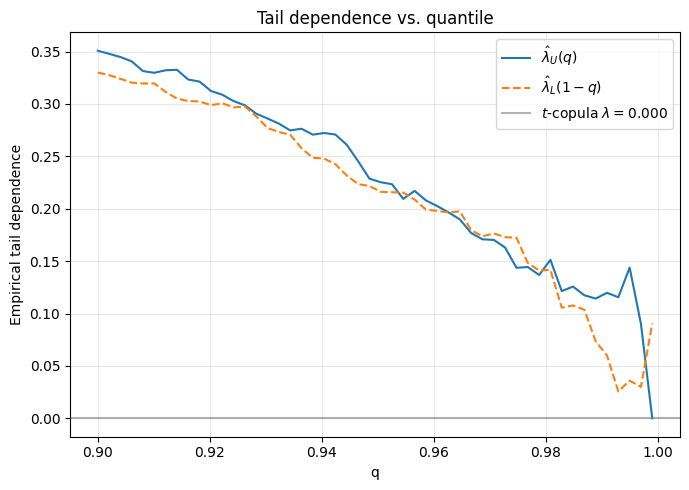

In [10]:
# --- Empirical tail dependence curves on q ∈ [0.90, 1.0) ---
# assumes U is an (n,2) array of uniforms in (0,1), and best_copula/best_params set

eps = 1e-12
Ue = np.clip(U, eps, 1 - eps)

q = np.linspace(0.90, 0.999, 50)        # avoid q=1
p = 1.0 - q                              # small tail probability

# Upper tail:  P(U1>q, U2>q)/(1-q)
joint_upper = ((Ue[:, 0, None] > q) & (Ue[:, 1, None] > q)).mean(axis=0)
lambda_U = joint_upper / p

# Lower tail:  P(U1<=p, U2<=p)/p  with p = 1-q
joint_lower = ((Ue[:, 0, None] <= p) & (Ue[:, 1, None] <= p)).mean(axis=0)
lambda_L = joint_lower / p

plt.figure(figsize=(7,5))
plt.plot(q, lambda_U, label=r'$\hat{\lambda}_U(q)$')
plt.plot(q, lambda_L, label=r'$\hat{\lambda}_L(1-q)$', linestyle='--')

# Optional: overlay asymptotic tail-dependence (constant) from fitted copula
if best_copula == 't_copula':
    rho, nu = best_params
    lam_asym = 2 * t.cdf(-np.sqrt(((nu + 1) * (1 - rho)) / (1 + rho)), df=nu + 1)
    plt.axhline(lam_asym, color='gray', alpha=0.6, label=fr'$t$-copula $\lambda={lam_asym:.3f}$')
elif best_copula == 'gaussian':
    plt.axhline(0.0, color='gray', alpha=0.6, label='Gaussian $\lambda=0$')

plt.xlabel('q')
plt.ylabel(r'Empirical tail dependence')
plt.title('Tail dependence vs. quantile')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()


## SYSEN Case Study
